<a href="https://colab.research.google.com/github/seitoalg/Market-Stress-and-Valuation-Risk-Strategy-Framework/blob/main/VIXDISTRIVER1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install yfinance -q

import yfinance as yf
import pandas as pd
import numpy as np
from scipy.stats import norm, shapiro, probplot, lognorm, skew, kurtosis
from dateutil.relativedelta import relativedelta
import matplotlib.pyplot as plt

===== Data Overview =====
Start date : 2006-06-13
End date   : 2026-06-12
Days       : 5033


,VIX_Close,Log_VIX_Close
Date,,
2006-06-13,23.809999,3.170106
2006-06-14,21.459999,3.066191
2006-06-15,15.900000,2.766319
2006-06-16,17.250000,2.847812
2006-06-19,17.830000,2.880882



===== Distribution Summary =====


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p
0,Raw VIX Close,5033,19.609768,8.691484,17.290001,9.14000,82.690002,2.506668,9.418504,0.783892,4.629548e-63
1,Log VIX Close,5033,2.903900,0.359526,2.850128,2.21266,4.415099,0.876638,1.020502,0.956528,3.171768e-36



===== Log(VIX Close) Parameters =====
mu              = 2.9039
sigma           = 0.3595
Geometric mean  = 18.25


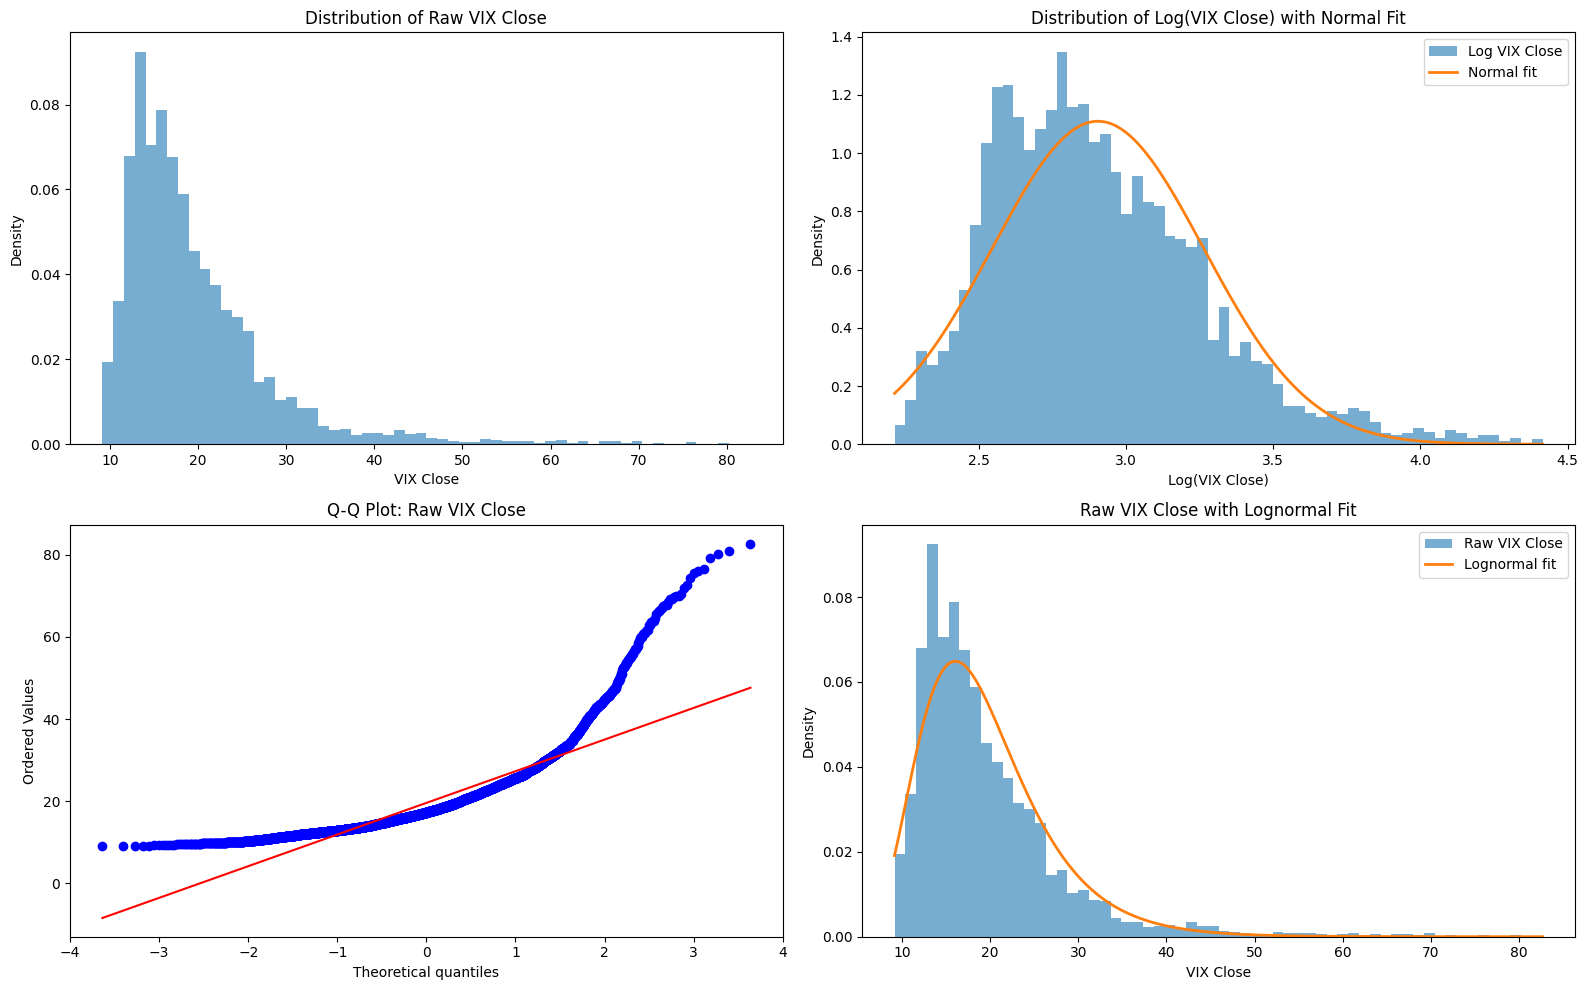

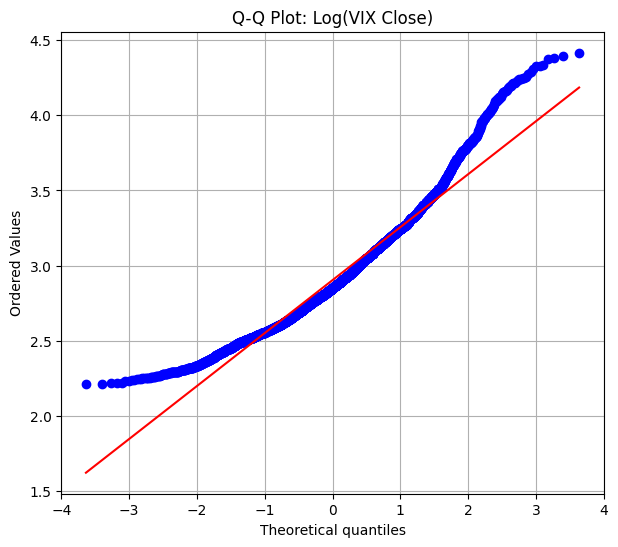

In [7]:
# ============================================================
# Cell 2: VIX Lognormal Distribution Check
# Daily Close-Based Baseline Test
# ============================================================
# Objective:
# 1. Check whether raw daily VIX close is strongly right-skewed.
# 2. Test whether log-transformed daily VIX close is closer to a normal distribution.
# 3. Evaluate whether raw VIX can be approximated by a lognormal distribution.
#
# Interpretation:
# - This cell is a baseline distribution check using daily VIX Close.
# - The main project later focuses on monthly VIX High.
# - Raw VIX is expected to be right-skewed.
# - Log(VIX) is expected to be closer to a normal distribution.
# - Shapiro-Wilk p-values should be interpreted carefully because
#   large financial datasets often reject normality even when the
#   practical fit is visually and statistically improved.
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

from scipy.stats import (
    skew,
    kurtosis,
    shapiro,
    norm,
    lognorm,
    probplot
)

from dateutil.relativedelta import relativedelta
import warnings

warnings.filterwarnings("ignore")

# -------------------------
# 1. Data collection
# -------------------------

today = pd.Timestamp.today().normalize()
start_date = today - relativedelta(years=20)

print("Downloading VIX data...")

vix_raw = yf.download("^VIX", start=start_date, progress=False)

# Use daily Close and convert it into a one-dimensional Series
close_series = vix_raw["Close"].squeeze()

# Create clean DataFrame
vix = pd.DataFrame()
vix["VIX_Close"] = close_series
vix = vix.dropna()

# Log transformation
vix["Log_VIX_Close"] = np.log(vix["VIX_Close"])

print("===== Data Overview =====")
print(f"Start date : {vix.index[0].date()}")
print(f"End date   : {vix.index[-1].date()}")
print(f"Days       : {len(vix)}")
display(vix.head())

# -------------------------
# 2. Helper function: distribution statistics
# -------------------------

def distribution_stats(series, name):
    clean = series.dropna()

    # Shapiro-Wilk is sensitive with large samples.
    # A capped random sample is used for stability and comparability.
    sample_size = min(5000, len(clean))
    sample = clean.sample(sample_size, random_state=42) if len(clean) > sample_size else clean

    shapiro_stat, shapiro_p = shapiro(sample)

    return pd.Series({
        "Name": name,
        "Count": len(clean),
        "Mean": clean.mean(),
        "Std": clean.std(),
        "Median": clean.median(),
        "Min": clean.min(),
        "Max": clean.max(),
        "Skewness": skew(clean),
        "Kurtosis_Excess": kurtosis(clean),
        "Shapiro_Stat": shapiro_stat,
        "Shapiro_p": shapiro_p
    })

# -------------------------
# 3. Raw vs Log distribution summary
# -------------------------

summary_stats = pd.DataFrame([
    distribution_stats(vix["VIX_Close"], "Raw VIX Close"),
    distribution_stats(vix["Log_VIX_Close"], "Log VIX Close")
])

print("\n===== Distribution Summary =====")
display(summary_stats)

# -------------------------
# 4. Lognormal parameter estimation
# -------------------------
# If Log(VIX) is approximately normal, then raw VIX can be viewed
# as approximately lognormal.
# -------------------------

mu = vix["Log_VIX_Close"].mean()
sigma = vix["Log_VIX_Close"].std()

geometric_mean = np.exp(mu)

print("\n===== Log(VIX Close) Parameters =====")
print(f"mu              = {mu:.4f}")
print(f"sigma           = {sigma:.4f}")
print(f"Geometric mean  = {geometric_mean:.2f}")

# -------------------------
# 5. Fitted distributions
# -------------------------

x_log = np.linspace(
    vix["Log_VIX_Close"].min(),
    vix["Log_VIX_Close"].max(),
    300
)

pdf_normal_log = norm.pdf(x_log, mu, sigma)

x_raw = np.linspace(
    vix["VIX_Close"].min(),
    vix["VIX_Close"].max(),
    300
)

pdf_lognormal_raw = lognorm.pdf(
    x_raw,
    s=sigma,
    scale=np.exp(mu)
)

# -------------------------
# 6. Visualization
# -------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw VIX distribution
axes[0, 0].hist(
    vix["VIX_Close"],
    bins=60,
    density=True,
    alpha=0.6
)

axes[0, 0].set_title("Distribution of Raw VIX Close")
axes[0, 0].set_xlabel("VIX Close")
axes[0, 0].set_ylabel("Density")

# Log VIX distribution with normal fit
axes[0, 1].hist(
    vix["Log_VIX_Close"],
    bins=60,
    density=True,
    alpha=0.6,
    label="Log VIX Close"
)

axes[0, 1].plot(
    x_log,
    pdf_normal_log,
    linewidth=2,
    label="Normal fit"
)

axes[0, 1].set_title("Distribution of Log(VIX Close) with Normal Fit")
axes[0, 1].set_xlabel("Log(VIX Close)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# Q-Q plot of raw VIX
probplot(
    vix["VIX_Close"],
    dist="norm",
    plot=axes[1, 0]
)

axes[1, 0].set_title("Q-Q Plot: Raw VIX Close")

# Raw VIX distribution with lognormal fit
axes[1, 1].hist(
    vix["VIX_Close"],
    bins=60,
    density=True,
    alpha=0.6,
    label="Raw VIX Close"
)

axes[1, 1].plot(
    x_raw,
    pdf_lognormal_raw,
    linewidth=2,
    label="Lognormal fit"
)

axes[1, 1].set_title("Raw VIX Close with Lognormal Fit")
axes[1, 1].set_xlabel("VIX Close")
axes[1, 1].set_ylabel("Density")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# -------------------------
# 7. Q-Q plot of Log VIX
# -------------------------
# This is separated because it is one of the most important diagnostics.
# -------------------------

plt.figure(figsize=(7, 6))

probplot(
    vix["Log_VIX_Close"],
    dist="norm",
    plot=plt
)

plt.title("Q-Q Plot: Log(VIX Close)")
plt.grid(True)
plt.show()

===== Data Overview =====
Start date : 1990-01-31
End date   : 2026-06-30
Months     : 438


,VIX_High,Log_VIX_High
Date,,
1990-01-31,27.250000,3.305054
1990-02-28,24.870001,3.213662
1990-03-31,22.740000,3.124125
1990-04-30,24.160000,3.184698
1990-05-31,20.139999,3.002708



===== Full-Period Distribution Summary =====


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p
0,Raw VIX Monthly High,438,24.830137,10.704489,22.27000,12.440000,89.529999,2.198173,7.596482,0.819134,7.716523e-22
1,Log VIX Monthly High,438,3.140176,0.363363,3.10324,2.520917,4.494574,0.709950,0.505027,0.965278,1.145254e-08


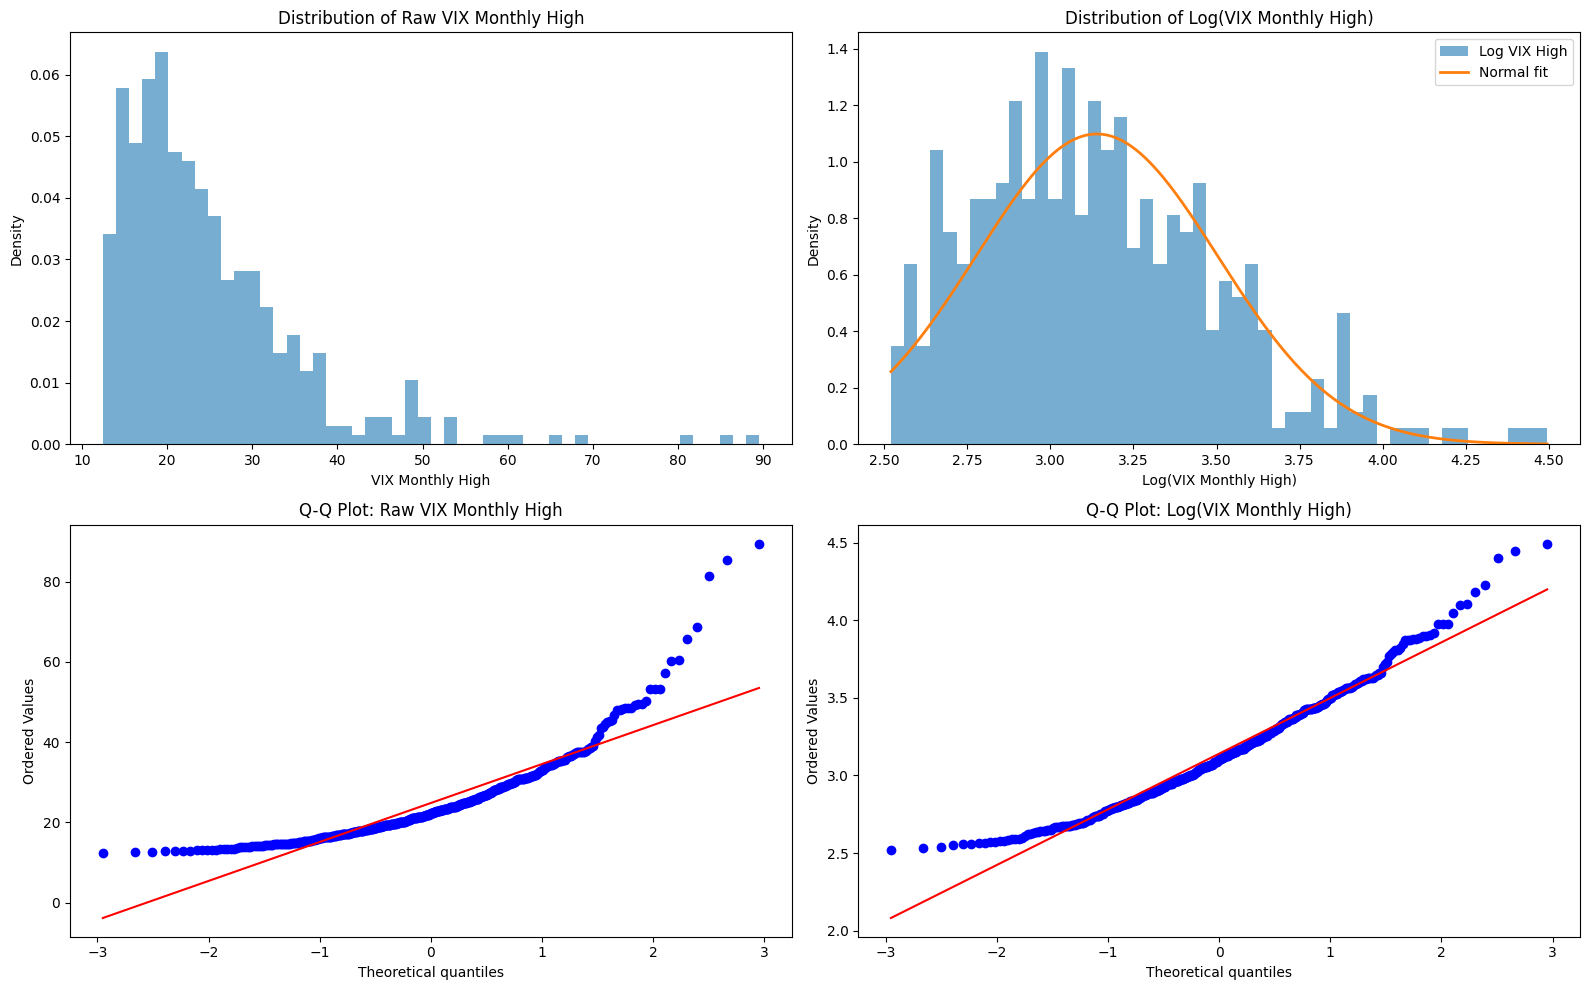


===== Regime Comparison: Log(VIX Monthly High) =====


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p
0,Full 1990-2026,438,3.140176,0.363363,3.103240,2.520917,4.494574,0.709950,0.505027,0.965278,1.145254e-08
1,1995-2007,156,3.121188,0.347778,3.124783,2.520917,3.902579,0.163410,-0.681362,0.973997,4.778046e-03
2,2008-2019,144,3.148009,0.390827,3.062688,2.556452,4.494574,1.005661,0.875112,0.932244,2.195293e-06
3,2020-2026,78,3.296207,0.356152,3.247649,2.660959,4.448165,0.710051,0.620243,0.964210,2.735785e-02
4,Post-2010,198,3.148892,0.351215,3.088538,2.556452,4.448165,0.803216,0.567564,0.957441,1.166192e-05


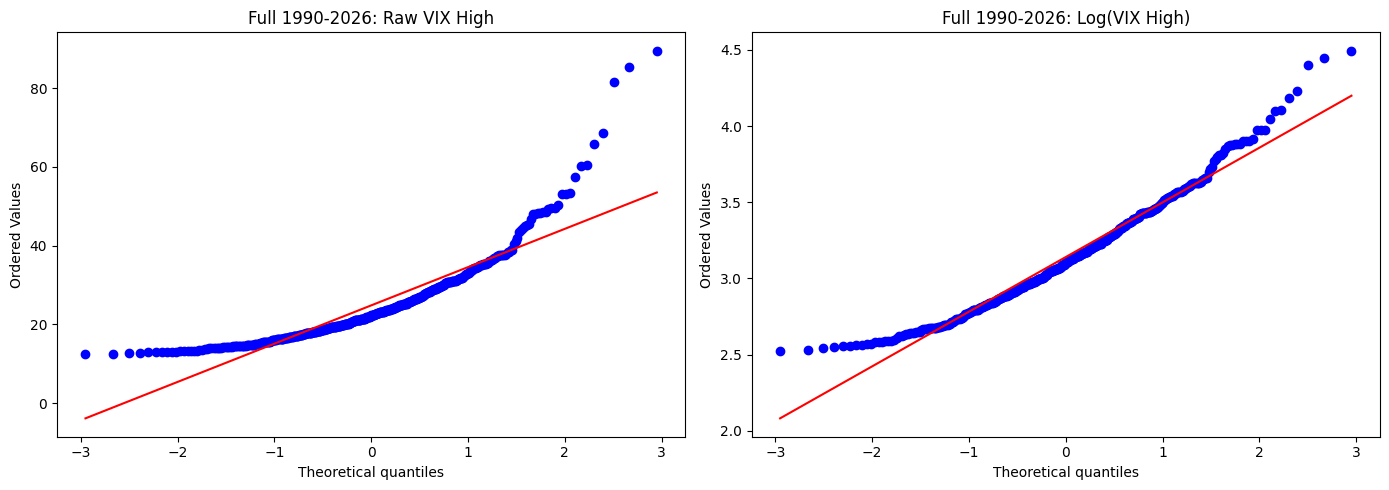

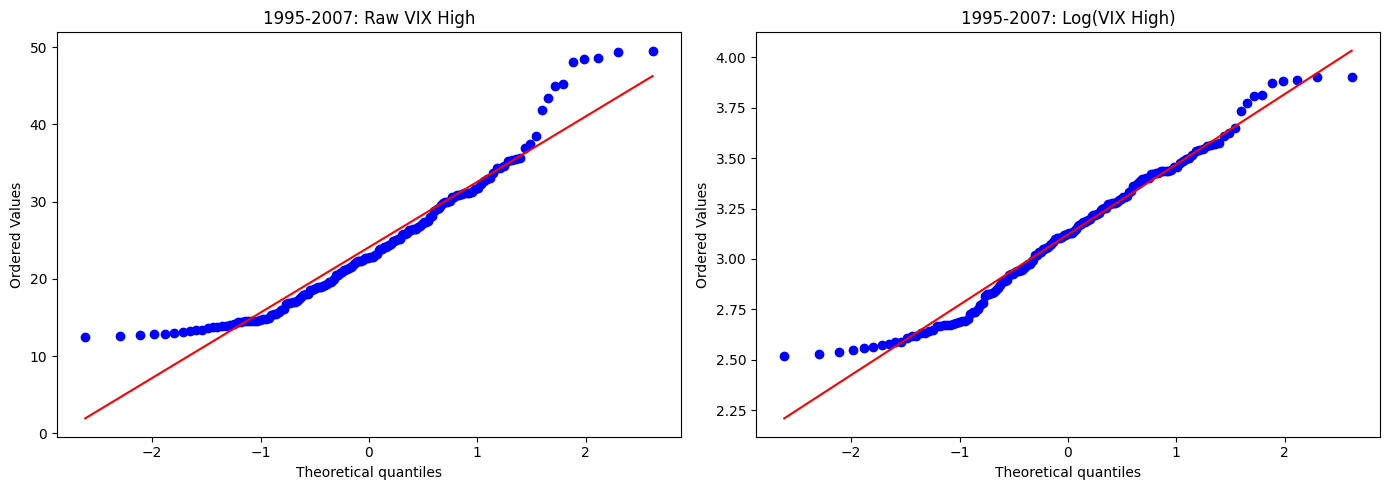

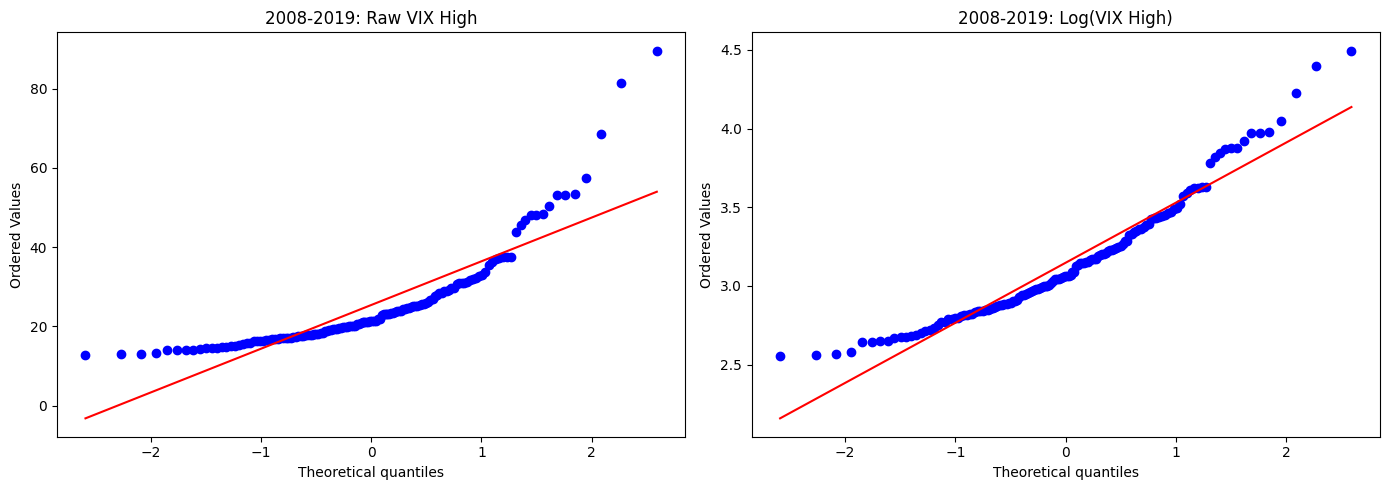

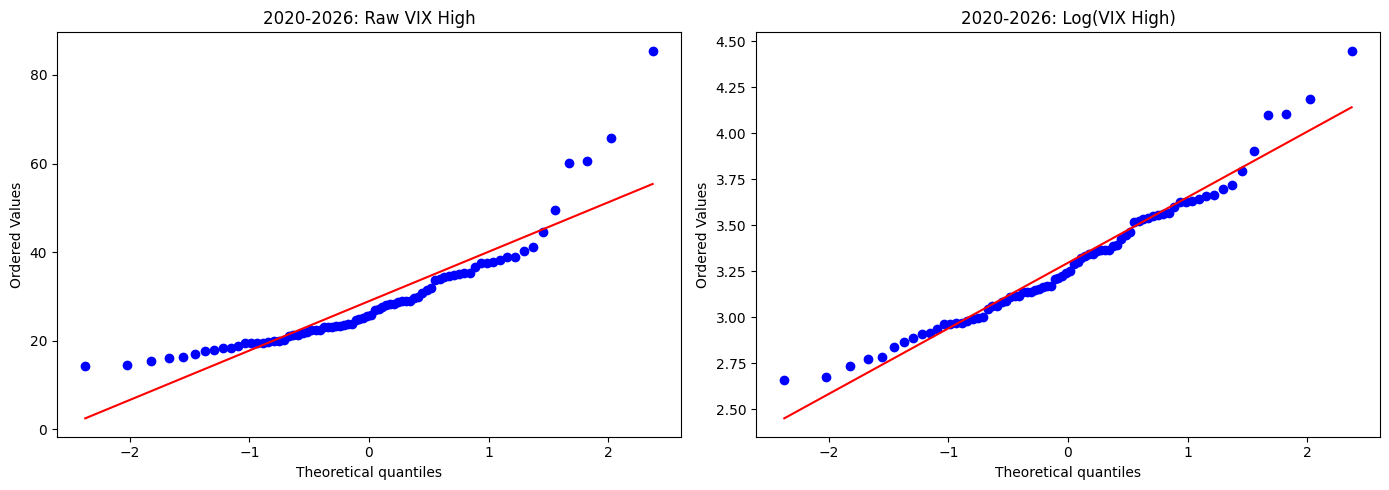

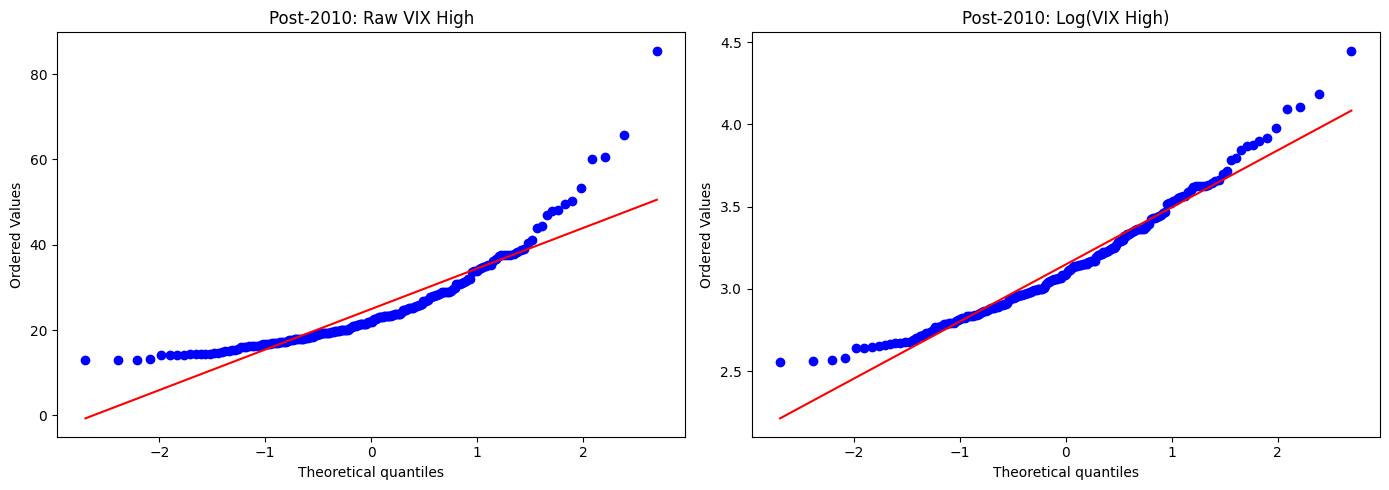


===== Adaptive Log-Z Score Summary =====


,Z_Log_Adaptive
count,438.000000
mean,0.070399
std,1.008024
min,-1.642319
25%,-0.670561
50%,-0.055135
75%,0.715948
max,3.894210



===== Adaptive Log-Z Score Distribution Check =====


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p,Actual_Z_Above_2,Actual_Z_Above_3
0,Adaptive Log-Z Score,438,0.070399,1.008024,-0.055135,-1.642319,3.89421,0.721478,0.522977,0.964085,7.174435e-09,0.052511,0.009132


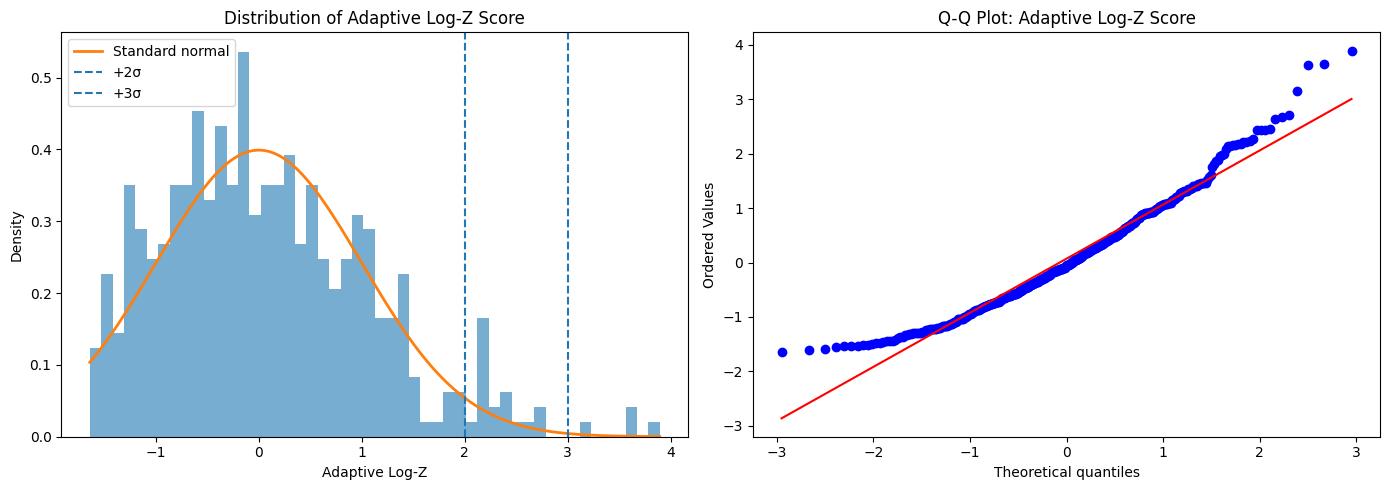


===== +2σ Stress-Tail Months =====


,VIX_High,Log_VIX_High,Log_Mean_30Y_Backfilled,Log_Std_30Y_Backfilled,Z_Log_Adaptive,VIX_Log_Based_Plus_2Sigma,VIX_Log_Based_Plus_3Sigma
Date,,,,,,,
1997-10-31,48.639999,3.884446,3.106369,0.356479,2.182672,45.573554,65.092327
1998-09-30,48.060001,3.872450,3.106369,0.356479,2.149020,45.573554,65.092327
1998-10-31,49.529999,3.902579,3.106369,0.356479,2.233537,45.573554,65.092327
2001-09-30,49.349998,3.898938,3.106369,0.356479,2.223323,45.573554,65.092327
2002-07-31,48.459999,3.880739,3.106369,0.356479,2.172271,45.573554,65.092327
2008-09-30,48.400002,3.879500,3.106369,0.356479,2.168796,45.573554,65.092327
2008-10-31,89.529999,4.494574,3.106369,0.356479,3.894210,45.573554,65.092327
2008-11-30,81.480003,4.400358,3.106369,0.356479,3.629913,45.573554,65.092327
2008-12-31,68.599998,4.228293,3.106369,0.356479,3.147234,45.573554,65.092327



===== Stress-Wave Summary =====


,Start_Date,End_Date,Months,Max_VIX_High,Max_Z
Wave_ID,,,,,
1,1997-10-31,1997-10-31,1,48.639999,2.182672
2,1998-09-30,1998-10-31,2,49.529999,2.233537
3,2001-09-30,2001-09-30,1,49.349998,2.223323
4,2002-07-31,2002-07-31,1,48.459999,2.172271
5,2008-09-30,2009-04-30,8,89.529999,3.894210
6,2010-05-31,2010-05-31,1,48.200001,2.157180
7,2011-08-31,2011-10-31,2,48.000000,2.145516
8,2015-08-31,2015-08-31,1,53.290001,2.438795
9,2018-02-28,2018-02-28,1,50.299999,2.276811



===== Raw Z vs Log Z Comparison =====


,Name,Count,Mean,Std,Median,Min,Max,Skewness,Kurtosis_Excess,Shapiro_Stat,Shapiro_p,Actual_Z_Above_2,Actual_Z_Above_3
0,Raw VIX Adaptive Z,438,0.061313,1.031844,-0.203583,-1.131623,6.451164,2.200546,7.652435,0.818521,7.138498e-22,0.057078,0.018265
1,Log VIX Adaptive Z,438,0.070399,1.008024,-0.055135,-1.642319,3.894210,0.721478,0.522977,0.964085,7.174435e-09,0.052511,0.009132


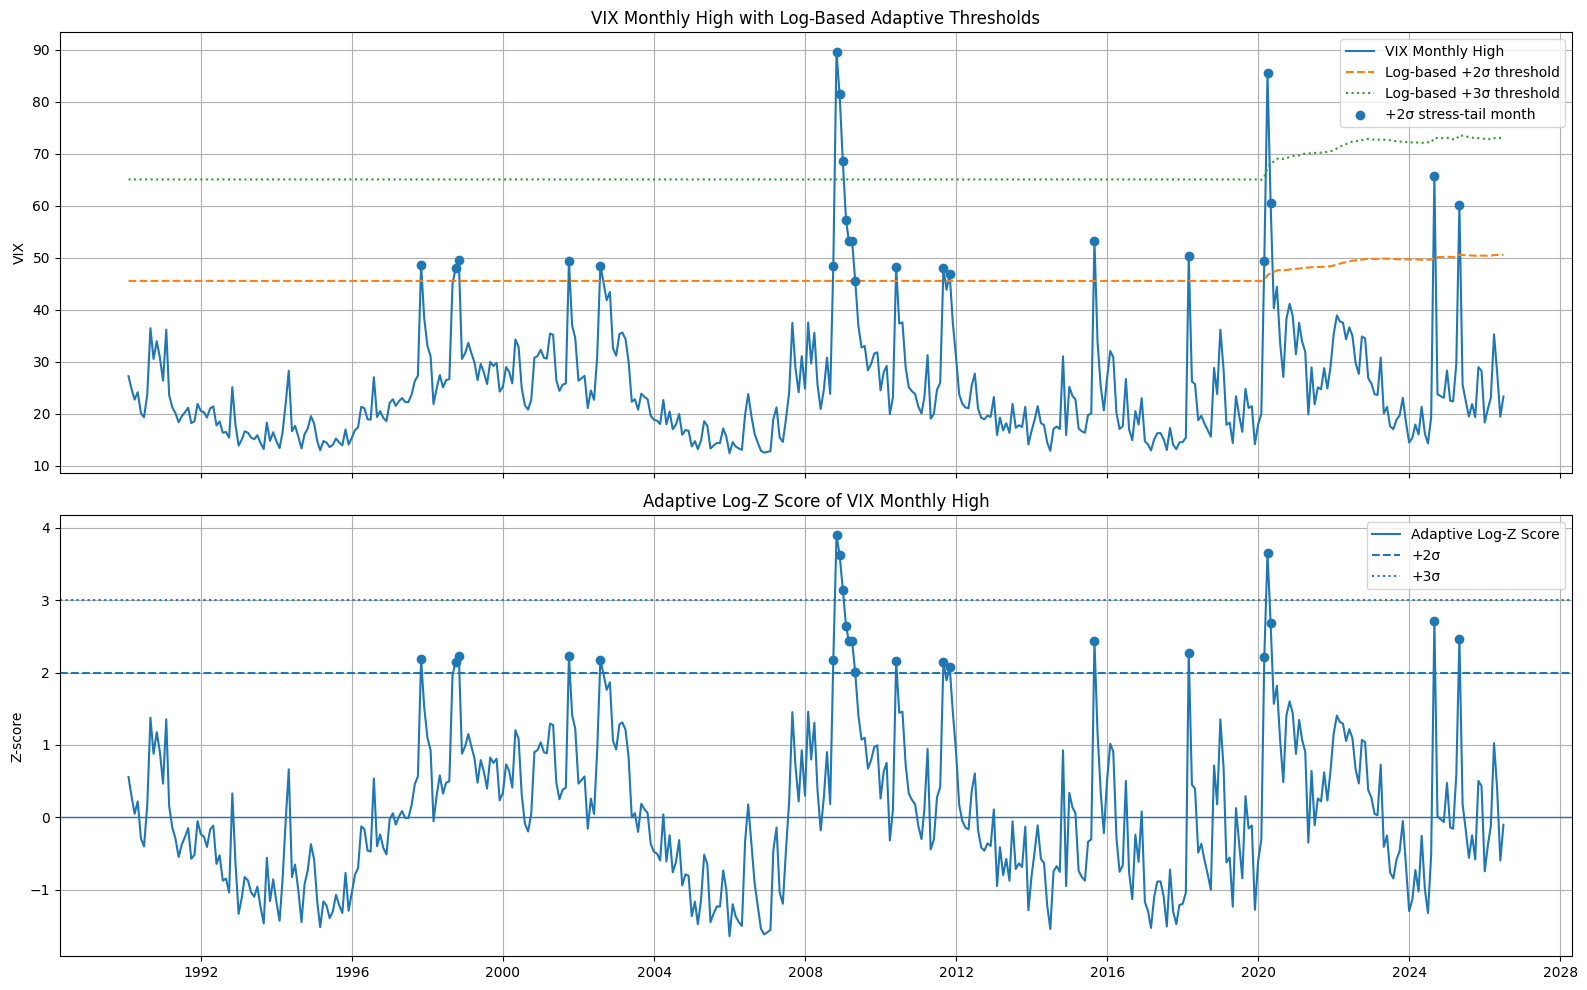

In [4]:
# ============================================================
# VIX Monthly High Distribution Check
# Regime Comparison + Adaptive Log-Z Score
# ============================================================
# Objective:
# 1. Convert daily VIX High into monthly VIX High.
# 2. Compare Raw VIX High and Log(VIX High) across regimes.
# 3. Check whether Log(VIX High) is closer to a normal distribution.
# 4. Build an adaptive Z-score using rolling mean and rolling std of Log(VIX High).
# 5. Identify +2σ and +3σ stress-tail months.
#
# Important interpretation:
# - This is a distribution-structure test, not a trading rule.
# - +2σ / +3σ months are not treated as model failures.
# - They are interpreted as VIX stress-tail events.
# - Backfilled early-window values are used only for research visualization,
#   not for real-time trading signal construction.
# ============================================================

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import skew, kurtosis, shapiro
import warnings

warnings.filterwarnings("ignore")

# -------------------------
# 1. Data collection
# -------------------------

print("Downloading VIX data...")

vix = yf.download("^VIX", start="1990-01-01", progress=False)

# Use daily High and convert it into a one-dimensional Series
high_series = vix["High"].squeeze()

# Create monthly VIX High
monthly_high = high_series.resample("ME").max()

monthly_df = pd.DataFrame()
monthly_df["VIX_High"] = monthly_high
monthly_df = monthly_df.dropna()

# Log transformation
monthly_df["Log_VIX_High"] = np.log(monthly_df["VIX_High"])

print("===== Data Overview =====")
print(f"Start date : {monthly_df.index[0].date()}")
print(f"End date   : {monthly_df.index[-1].date()}")
print(f"Months     : {len(monthly_df)}")
display(monthly_df.head())

# -------------------------
# 2. Helper function: distribution statistics
# -------------------------

def distribution_stats(series, name):
    clean = series.dropna()

    # Shapiro-Wilk can be overly sensitive with large samples.
    # It is used together with skewness, kurtosis, histograms, and Q-Q plots.
    sample_size = min(5000, len(clean))
    sample = clean.sample(sample_size, random_state=42) if len(clean) > sample_size else clean

    shapiro_stat, shapiro_p = shapiro(sample)

    return pd.Series({
        "Name": name,
        "Count": len(clean),
        "Mean": clean.mean(),
        "Std": clean.std(),
        "Median": clean.median(),
        "Min": clean.min(),
        "Max": clean.max(),
        "Skewness": skew(clean),
        "Kurtosis_Excess": kurtosis(clean),
        "Shapiro_Stat": shapiro_stat,
        "Shapiro_p": shapiro_p
    })

# -------------------------
# 3. Full-period Raw vs Log comparison
# -------------------------

summary = pd.DataFrame([
    distribution_stats(monthly_df["VIX_High"], "Raw VIX Monthly High"),
    distribution_stats(monthly_df["Log_VIX_High"], "Log VIX Monthly High")
])

print("\n===== Full-Period Distribution Summary =====")
display(summary)

# -------------------------
# 4. Raw vs Log visualization
# -------------------------

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Raw VIX High histogram
axes[0, 0].hist(monthly_df["VIX_High"], bins=50, density=True, alpha=0.6)
axes[0, 0].set_title("Distribution of Raw VIX Monthly High")
axes[0, 0].set_xlabel("VIX Monthly High")
axes[0, 0].set_ylabel("Density")

# Log VIX High histogram with normal fit
log_data = monthly_df["Log_VIX_High"].dropna()
mu = log_data.mean()
sigma = log_data.std()

x_log = np.linspace(log_data.min(), log_data.max(), 300)
pdf_log = stats.norm.pdf(x_log, mu, sigma)

axes[0, 1].hist(log_data, bins=50, density=True, alpha=0.6, label="Log VIX High")
axes[0, 1].plot(x_log, pdf_log, linewidth=2, label="Normal fit")
axes[0, 1].set_title("Distribution of Log(VIX Monthly High)")
axes[0, 1].set_xlabel("Log(VIX Monthly High)")
axes[0, 1].set_ylabel("Density")
axes[0, 1].legend()

# Raw VIX High Q-Q plot
stats.probplot(monthly_df["VIX_High"].dropna(), dist="norm", plot=axes[1, 0])
axes[1, 0].set_title("Q-Q Plot: Raw VIX Monthly High")

# Log VIX High Q-Q plot
stats.probplot(log_data, dist="norm", plot=axes[1, 1])
axes[1, 1].set_title("Q-Q Plot: Log(VIX Monthly High)")

plt.tight_layout()
plt.show()

# -------------------------
# 5. Regime comparison
# -------------------------

periods = {
    "Full 1990-2026": slice(None, None),
    "1995-2007": slice("1995-01-01", "2007-12-31"),
    "2008-2019": slice("2008-01-01", "2019-12-31"),
    "2020-2026": slice("2020-01-01", None),
    "Post-2010": slice("2010-01-01", None)
}

period_results = []

for period_name, period_slice in periods.items():
    subset = monthly_df.loc[period_slice].copy()

    if len(subset) < 10:
        continue

    period_results.append(
        distribution_stats(subset["Log_VIX_High"], period_name)
    )

period_summary = pd.DataFrame(period_results)

print("\n===== Regime Comparison: Log(VIX Monthly High) =====")
display(period_summary)

# -------------------------
# 6. Regime Q-Q plots
# -------------------------

for period_name, period_slice in periods.items():
    subset = monthly_df.loc[period_slice].copy()

    if len(subset) < 10:
        continue

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    stats.probplot(subset["VIX_High"].dropna(), dist="norm", plot=axes[0])
    axes[0].set_title(f"{period_name}: Raw VIX High")

    stats.probplot(subset["Log_VIX_High"].dropna(), dist="norm", plot=axes[1])
    axes[1].set_title(f"{period_name}: Log(VIX High)")

    plt.tight_layout()
    plt.show()

# -------------------------
# 7. Adaptive Z-score using rolling Log mean and rolling Log std
# -------------------------
# Correct approach:
# The distribution being tested is Log(VIX High).
# Therefore, the rolling center should be the rolling mean of Log(VIX High),
# not log of the rolling mean of raw VIX High.
# -------------------------

window_months = 360
min_periods = 360

monthly_df["Log_Mean_30Y"] = (
    monthly_df["Log_VIX_High"]
    .rolling(window=window_months, min_periods=min_periods)
    .mean()
)

monthly_df["Log_Std_30Y"] = (
    monthly_df["Log_VIX_High"]
    .rolling(window=window_months, min_periods=min_periods)
    .std()
)

# First available 30-year parameters
first_valid_idx = monthly_df["Log_Mean_30Y"].first_valid_index()

first_log_mean = monthly_df.loc[first_valid_idx, "Log_Mean_30Y"]
first_log_std = monthly_df.loc[first_valid_idx, "Log_Std_30Y"]

# Backfill early-period parameters for research visualization only
monthly_df["Log_Mean_30Y_Backfilled"] = monthly_df["Log_Mean_30Y"].copy()
monthly_df["Log_Std_30Y_Backfilled"] = monthly_df["Log_Std_30Y"].copy()

monthly_df.loc[:first_valid_idx, "Log_Mean_30Y_Backfilled"] = first_log_mean
monthly_df.loc[:first_valid_idx, "Log_Std_30Y_Backfilled"] = first_log_std

# Adaptive Z-score
monthly_df["Z_Log_Adaptive"] = (
    monthly_df["Log_VIX_High"] - monthly_df["Log_Mean_30Y_Backfilled"]
) / monthly_df["Log_Std_30Y_Backfilled"]

# Convert log-based +2σ and +3σ thresholds back into raw VIX levels
monthly_df["VIX_Log_Based_Plus_2Sigma"] = np.exp(
    monthly_df["Log_Mean_30Y_Backfilled"] + 2 * monthly_df["Log_Std_30Y_Backfilled"]
)

monthly_df["VIX_Log_Based_Plus_3Sigma"] = np.exp(
    monthly_df["Log_Mean_30Y_Backfilled"] + 3 * monthly_df["Log_Std_30Y_Backfilled"]
)

print("\n===== Adaptive Log-Z Score Summary =====")
display(monthly_df["Z_Log_Adaptive"].describe())

# -------------------------
# 8. Adaptive Z-score diagnostics
# -------------------------

z_data = monthly_df["Z_Log_Adaptive"].dropna()

z_summary = pd.DataFrame([
    distribution_stats(z_data, "Adaptive Log-Z Score")
])

z_summary["Actual_Z_Above_2"] = (z_data > 2).mean()
z_summary["Actual_Z_Above_3"] = (z_data > 3).mean()

print("\n===== Adaptive Log-Z Score Distribution Check =====")
display(z_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(z_data, bins=50, density=True, alpha=0.6)
x_z = np.linspace(z_data.min(), z_data.max(), 300)
axes[0].plot(x_z, stats.norm.pdf(x_z, 0, 1), linewidth=2, label="Standard normal")
axes[0].axvline(2, linestyle="--", label="+2σ")
axes[0].axvline(3, linestyle="--", label="+3σ")
axes[0].set_title("Distribution of Adaptive Log-Z Score")
axes[0].set_xlabel("Adaptive Log-Z")
axes[0].set_ylabel("Density")
axes[0].legend()

stats.probplot(z_data, dist="norm", plot=axes[1])
axes[1].set_title("Q-Q Plot: Adaptive Log-Z Score")

plt.tight_layout()
plt.show()

# -------------------------
# 9. Stress-tail event extraction
# -------------------------

monthly_df["Stress_Event_2Sigma"] = monthly_df["Z_Log_Adaptive"] > 2
monthly_df["Stress_Event_3Sigma"] = monthly_df["Z_Log_Adaptive"] > 3

events_2sigma = monthly_df.loc[
    monthly_df["Stress_Event_2Sigma"],
    [
        "VIX_High",
        "Log_VIX_High",
        "Log_Mean_30Y_Backfilled",
        "Log_Std_30Y_Backfilled",
        "Z_Log_Adaptive",
        "VIX_Log_Based_Plus_2Sigma",
        "VIX_Log_Based_Plus_3Sigma"
    ]
].copy()

print("\n===== +2σ Stress-Tail Months =====")
display(events_2sigma)

# -------------------------
# 10. Stress-wave clustering
# -------------------------
# Consecutive or nearby stress months are grouped into the same wave.
# A new wave starts when the gap from the previous stress month is larger than 3 months.
# -------------------------

events_2sigma = events_2sigma.copy()

if len(events_2sigma) > 0:
    events_2sigma["Month_Gap"] = (
        events_2sigma.index.to_series().diff().dt.days / 30.44
    )

    events_2sigma["New_Wave"] = (
        events_2sigma["Month_Gap"].isna() |
        (events_2sigma["Month_Gap"] > 3)
    )

    events_2sigma["Wave_ID"] = events_2sigma["New_Wave"].cumsum()

    wave_summary = events_2sigma.groupby("Wave_ID").agg(
        Start_Date=("VIX_High", lambda x: x.index.min()),
        End_Date=("VIX_High", lambda x: x.index.max()),
        Months=("VIX_High", "count"),
        Max_VIX_High=("VIX_High", "max"),
        Max_Z=("Z_Log_Adaptive", "max")
    )

    print("\n===== Stress-Wave Summary =====")
    display(wave_summary)
else:
    print("\nNo +2σ stress-tail months found.")

# -------------------------
# 11. Raw VIX rolling Z-score comparison
# -------------------------
# This is only a comparison benchmark.
# The main distribution model is based on Log(VIX High).
# -------------------------

monthly_df["Raw_Mean_30Y"] = (
    monthly_df["VIX_High"]
    .rolling(window=window_months, min_periods=min_periods)
    .mean()
)

monthly_df["Raw_Std_30Y"] = (
    monthly_df["VIX_High"]
    .rolling(window=window_months, min_periods=min_periods)
    .std()
)

first_raw_mean = monthly_df.loc[first_valid_idx, "Raw_Mean_30Y"]
first_raw_std = monthly_df.loc[first_valid_idx, "Raw_Std_30Y"]

monthly_df["Raw_Mean_30Y_Backfilled"] = monthly_df["Raw_Mean_30Y"].copy()
monthly_df["Raw_Std_30Y_Backfilled"] = monthly_df["Raw_Std_30Y"].copy()

monthly_df.loc[:first_valid_idx, "Raw_Mean_30Y_Backfilled"] = first_raw_mean
monthly_df.loc[:first_valid_idx, "Raw_Std_30Y_Backfilled"] = first_raw_std

monthly_df["Z_Raw_Adaptive"] = (
    monthly_df["VIX_High"] - monthly_df["Raw_Mean_30Y_Backfilled"]
) / monthly_df["Raw_Std_30Y_Backfilled"]

raw_vs_log_z = pd.DataFrame([
    distribution_stats(monthly_df["Z_Raw_Adaptive"], "Raw VIX Adaptive Z"),
    distribution_stats(monthly_df["Z_Log_Adaptive"], "Log VIX Adaptive Z")
])

raw_vs_log_z["Actual_Z_Above_2"] = [
    (monthly_df["Z_Raw_Adaptive"] > 2).mean(),
    (monthly_df["Z_Log_Adaptive"] > 2).mean()
]

raw_vs_log_z["Actual_Z_Above_3"] = [
    (monthly_df["Z_Raw_Adaptive"] > 3).mean(),
    (monthly_df["Z_Log_Adaptive"] > 3).mean()
]

print("\n===== Raw Z vs Log Z Comparison =====")
display(raw_vs_log_z)

# -------------------------
# 12. Final visualization
# -------------------------

fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# VIX High with log-based thresholds
axes[0].plot(monthly_df.index, monthly_df["VIX_High"], label="VIX Monthly High")
axes[0].plot(
    monthly_df.index,
    monthly_df["VIX_Log_Based_Plus_2Sigma"],
    linestyle="--",
    label="Log-based +2σ threshold"
)
axes[0].plot(
    monthly_df.index,
    monthly_df["VIX_Log_Based_Plus_3Sigma"],
    linestyle=":",
    label="Log-based +3σ threshold"
)

axes[0].scatter(
    monthly_df.loc[monthly_df["Stress_Event_2Sigma"]].index,
    monthly_df.loc[monthly_df["Stress_Event_2Sigma"], "VIX_High"],
    label="+2σ stress-tail month",
    zorder=5
)

axes[0].set_title("VIX Monthly High with Log-Based Adaptive Thresholds")
axes[0].set_ylabel("VIX")
axes[0].legend()
axes[0].grid(True)

# Adaptive Log-Z score
axes[1].plot(monthly_df.index, monthly_df["Z_Log_Adaptive"], label="Adaptive Log-Z Score")
axes[1].axhline(0, linewidth=1)
axes[1].axhline(2, linestyle="--", label="+2σ")
axes[1].axhline(3, linestyle=":", label="+3σ")

axes[1].scatter(
    monthly_df.loc[monthly_df["Stress_Event_2Sigma"]].index,
    monthly_df.loc[monthly_df["Stress_Event_2Sigma"], "Z_Log_Adaptive"],
    zorder=5
)

axes[1].set_title("Adaptive Log-Z Score of VIX Monthly High")
axes[1].set_ylabel("Z-score")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()